In [2]:
!pip install git+https://github.com/huggingface/transformers.git

import torch
from PIL import Image
from transformers import pipeline

# 1. Initialize the DALL-E mini pipeline
# This model generates images from text prompts.
# The first time you run this, it will download the model, which might take a few minutes.
print("Initializing DALL-E mini model...")
generator = pipeline("text-to-image", model="dalle-mini/dalle-mini")
print("Model initialized!")

# 2. Define your text prompt
prompt = "A cat riding a bicycle in space, digital art"
print(f"\nGenerating an image for the prompt: '{prompt}'")

# 3. Generate the image
# You can adjust the num_inference_steps for faster (lower number) or higher quality (higher number) generation.
# Higher steps takes longer.
image_output = generator(prompt, num_inference_steps=50)

# The output is typically a list of PIL Image objects. We'll take the first one.
if image_output and len(image_output) > 0:
    generated_image = image_output[0]

    # 4. Display the generated image
    print("\nGenerated Image:")
    display(generated_image) # In Colab, 'display' shows the image directly.

    # Optional: Save the image
    # generated_image.save("dalle_mini_output.png")
    # print("Image saved as 'dalle_mini_output.png'")
else:
    print("No image was generated.")


  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-f_0a6z_2
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-f_0a6z_2
  Resolved https://github.com/huggingface/transformers.git to commit e12f6ef656e2f9e08f2216515a1666ef91e6bcdf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.13.0.dev0-py3-none-any.whl size=12331588 sha256=a7ad4ad576325103382cb45e966404bb41ab2fda5b32c75879d7d2a67ec1ea82
  Stored in directory: /tmp/pip-ephem-wheel-cache-l3w53i7e/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.10.2
    Uninstalling transformers-5.10.2:
      Successfully uninstalled transformers-5.10.2


Initializing DALL-E mini model...


ValueError: The checkpoint you are trying to load has model type `dallebart` but Transformers does not recognize this architecture. This could be because of an issue with the checkpoint, or because your version of Transformers is out of date.

You can update Transformers with the command `pip install --upgrade transformers`. If this does not work, and the checkpoint is very new, then there may not be a release version that supports this model yet. In this case, you can get the most up-to-date code by installing Transformers from source with the command `pip install git+https://github.com/huggingface/transformers.git`

### Switching to Stable Diffusion for Text-to-Image Generation

Given the persistent issues with DALL-E mini, we will now use Stable Diffusion, a powerful and widely adopted text-to-image model. This requires the `diffusers` library from Hugging Face.

First, we need to install the `diffusers` library, and optionally `accelerate` for faster inference.

In [1]:
!pip install diffusers transformers accelerate


Now, let's set up the Stable Diffusion pipeline and generate an image. This might also involve downloading the model weights the first time, which can take some time depending on your internet connection.

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Stable Diffusion model loaded!

Generating an image for the prompt: 'A cat riding a bicycle in space, digital art, high detail, vibrant colors'


  0%|          | 0/30 [00:00<?, ?it/s]


Generated Image:


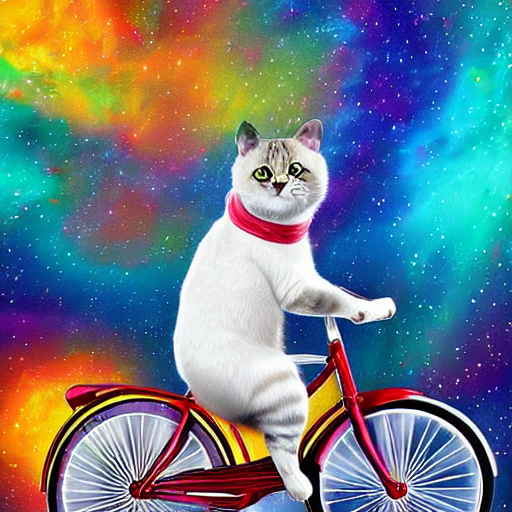

In [2]:
from diffusers import StableDiffusionPipeline
import torch
from PIL import Image

# 1. Load the pre-trained Stable Diffusion model
# This will download the model weights (around 4-7 GB) the first time it's run.
# We'll use a smaller, faster model for demonstration.
# Using 'stabilityai/stable-diffusion-2-1-base' as an example, you can explore others on Hugging Face.

# Check if CUDA is available for GPU acceleration, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

pipeline = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16 if device == "cuda" else torch.float32)
pipeline.to(device)
print("Stable Diffusion model loaded!")

# 2. Define your text prompt
prompt = "A cat riding a bicycle in space, digital art, high detail, vibrant colors"
print(f"\nGenerating an image for the prompt: '{prompt}'")

# 3. Generate the image
# You can adjust num_inference_steps for quality vs. speed. Guidance_scale influences how much the model follows the prompt.
image = pipeline(prompt, num_inference_steps=30, guidance_scale=7.5).images[0]

# 4. Display the generated image
print("\nGenerated Image:")
display(image)

# Optional: Save the image
# image.save("stable_diffusion_output.png")
# print("Image saved as 'stable_diffusion_output.png'")
